In [204]:
# 1. Imports y carga del dataset.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, label_binarize
from sklearn.metrics import classification_report, accuracy_score, make_scorer, confusion_matrix, cohen_kappa_score, f1_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import glob
import gc # Garbage Collector para limpiar la RAM
import xgboost as xgb
from xgboost import XGBClassifier

In [205]:
#2. Carga del dataset.
df_train = pd.read_csv("Data/train.csv")

In [206]:
#Funciones auxiliares

def compare_models(y_test, y_pred, models):
    mod= models
    acu = []
    kap = []
    f1 = []
    for pred in y_pred:
        acu.append(accuracy_score(y_test, pred))
        kap.append(cohen_kappa_score(y_test, pred, weights='quadratic'))
        f1.append(f1_score(y_test, pred, average='weighted'))

    return pd.DataFrame({
        "Model": mod,
        "Accuracy": acu,
        "QWK": kap,
        "f1_Score": f1
    })

def display_professional_eval(model, modelName, X_test, y_true, y_pred, cv_res, feature_names, top_n=20):
    sns.set_theme(style="whitegrid")
    
    # 1. Verificar si el modelo tiene importancia de variables
    has_importance = hasattr(model, 'feature_importances_')

    # 2. Configurar la figura (Si tiene importancia, 2 filas; si no, 1 fila)
    if has_importance:
        fig = plt.figure(figsize=(16, 12))
        gs = fig.add_gridspec(2, 2)
        ax1 = fig.add_subplot(gs[0, 0]) # Matriz
        ax2 = fig.add_subplot(gs[0, 1]) # ROC
        ax3 = fig.add_subplot(gs[1, :]) # Importancia (ocupa toda la fila)
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- IMPRESIÓN DE TEXTO (Igual a tu código) ---
    print("="*60)
    print(f"{'REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII':^60}")
    print("="*60)
    print(f"\n[ESTABILIDAD - CROSS VALIDATION (K=5)]")
    print(f"  > Accuracy: {cv_res['test_accuracy'].mean():.4f} ± {cv_res['test_accuracy'].std() * 2:.4f}")
    print(f"  > QWK: {cv_res['test_quadratic_kappa'].mean():.4f} ± {cv_res['test_quadratic_kappa'].std() * 2:.4f}")
    print(f"\n[DESEMPEÑO EN SET DE PRUEBA]")
    print(classification_report(y_true, y_pred))

    # --- GRÁFICA 1: MATRIZ DE CONFUSIÓN ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False, linewidths=0.2, linecolor='0.8')
    ax1.set_title('Matriz de Confusión: Real vs Predicción '+ modelName, fontweight='bold')
    ax1.set_xticklabels(['0', '1', '2', '3'])
    ax1.set_yticklabels(['0', '1', '2', '3'])

    # --- GRÁFICA 2: CURVA ROC ---
    y_test_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
    n_classes = y_test_bin.shape[1]
    # OJO: Aquí corregí y_true por X_test en predict_proba
    y_score = model.predict_proba(X_test) 
    
    colors = plt.cm.Blues(np.linspace(0.4, 1.0, n_classes))
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        ax2.plot(fpr, tpr, color=color, lw=2, label=f'Nivel {i} (AUC = {auc(fpr, tpr):.2f})')
    
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax2.set_title('Curvas ROC Multiclase ' + modelName, fontweight='bold')
    ax2.set_xlabel('Falsos Positivos')
    ax2.set_ylabel('Verdaderos Positivos')
    ax2.legend(loc="lower right")

    # --- GRÁFICA 3: IMPORTANCIA DE VARIABLES (Si aplica) ---
    if has_importance:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-top_n:]
        
        # 1. Cambiamos ax.barh por ax.bar
        # x = las posiciones (range), height = los valores de importancia
        ax3.bar(range(len(indices)), importances[indices], color=plt.cm.Blues(0.8))
        
        # 2. Los nombres ahora van en el eje X (xticks)
        ax3.set_xticks(range(len(indices)))
        
        # 3. ROTACIÓN CRÍTICA: Aquí es donde rotamos para que se lean los nombres
        ax3.set_xticklabels([feature_names[i] for i in indices], 
                            rotation=25,       # 45 grados es lo ideal para etiquetas en X
                            ha='right',        # Alineación para que el final del texto coincida con la barra
                            fontsize=10)
        
        ax3.set_title(f"Top {top_n} Variables más Influyentes", fontweight='bold')
        ax3.set_ylabel("Ganancia (Importance)") # El label ahora va en Y
        ax3.set_xlabel("Variables")             # El label ahora va en X

    plt.tight_layout()
    plt.show()

    # Mostrar tabla de importancia si existe
    if has_importance:
        importancia_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importancia_df = importancia_df.sort_values(by='Importance', ascending=False)
        display(importancia_df.head(top_n))



def get_top_correlations(corr_matrix):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    corr_pairs = upper_triangle.stack().reset_index()
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    sorted_pairs = corr_pairs.assign(abs_corr=corr_pairs['Correlation'].abs()) \
                             .sort_values(by='abs_corr', ascending=False) \
                             .drop(columns=['abs_corr'])

    return sorted_pairs.reset_index(drop=True)

def num_correlation_classifier(df, target, threshold=0.0, sort_by_abs=True):
    corr = df.corr(numeric_only=True)[target].drop(target)
    corr_df = (
        corr.reset_index()
        .rename(columns={"index": "feature", target: "correlation"})
    )
    corr_df["direction"] = corr_df["correlation"].apply(
        lambda x: "positive" if x > 0 else "negative"
    )
    def classify_strength(c):
        c = abs(c)
        if c < 0.1:
            return "very weak"
        elif c < 0.3:
            return "weak"
        elif c < 0.5:
            return "moderate"
        elif c < 0.7:
            return "strong"
        else:
            return "very strong"
    corr_df["strength"] = corr_df["correlation"].apply(classify_strength)
    corr_df["abs_correlation"] = corr_df["correlation"].abs()
    corr_df = corr_df[corr_df["abs_correlation"] >= threshold]
    if sort_by_abs:
        corr_df = corr_df.sort_values("abs_correlation", ascending=False)
    else:
        corr_df = corr_df.sort_values("correlation", ascending=False)
    corr_df = corr_df.reset_index(drop=True)
    return corr_df


def num_analysis(df, target):
    corr = df.corr(numeric_only=True)
    if target in corr.columns:
        corr_y = corr[target].drop(target).sort_values()
        plt.figure(figsize=(10,10))
        corr_y.plot(kind='barh')
        plt.title(f'Correlation with {target}')
        plt.xlabel('Correlation')
        plt.ylabel('Features')
        plt.show()


def get_top_correlations(corr_matrix):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_triangle = corr_matrix.where(mask)
    corr_pairs = upper_triangle.stack().reset_index()
    corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    sorted_pairs = corr_pairs.assign(abs_corr=corr_pairs['Correlation'].abs()) \
                             .sort_values(by='abs_corr', ascending=False) \
                             .drop(columns=['abs_corr'])

    return sorted_pairs.reset_index(drop=True)

def drop_features(X):
    X = X.drop(columns=unused_features, errors='ignore')
    return X


drop_features_transformer = FunctionTransformer(drop_features).set_output(transform="pandas")





In [4]:
#3 Se revisan tipo de variblaes y cantidad de nulos
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   object 
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   object 
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference            898 non-null    floa

sii
False    0.690909
True     0.309091
Name: proportion, dtype: float64
sii
0.0    0.582602
1.0    0.266813
2.0    0.138158
3.0    0.012427
Name: proportion, dtype: float64


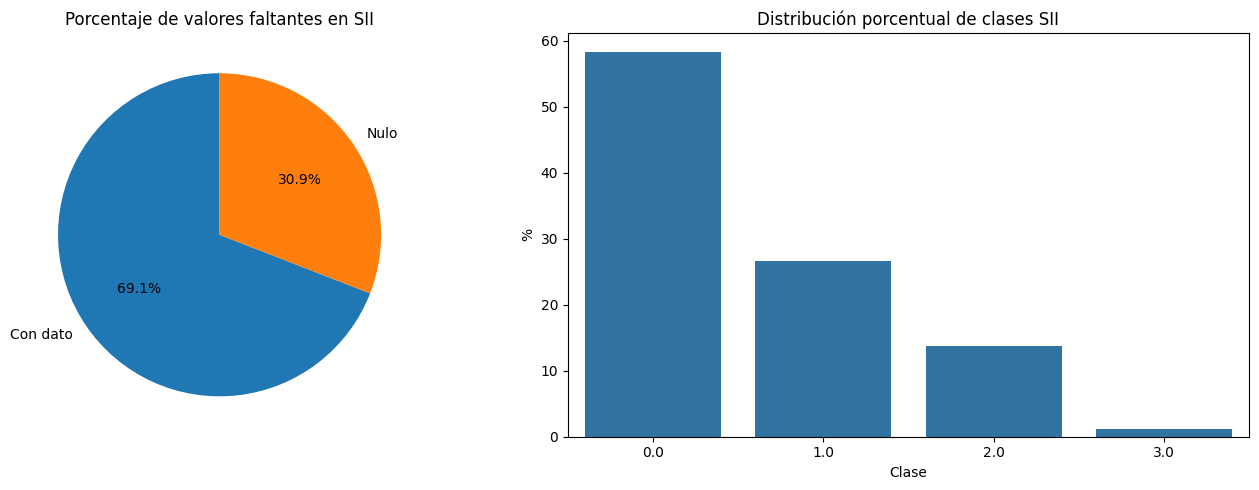

In [5]:
#4 Se revisa cantidad de nulos en variable objetivo y destribución de clases
print(df_train["sii"].isnull().value_counts(normalize=True))
print(df_train["sii"].value_counts(normalize=True))

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Nulos %
null_pct = df_train["sii"].isnull().value_counts(normalize=True)*100

axes[0].pie(
    null_pct,
    labels=["Con dato", "Nulo"],
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Porcentaje de valores faltantes en SII")

# Clases %
class_pct = df_train["sii"].value_counts(normalize=True).sort_index()*100

sns.barplot(
    x=class_pct.index,
    y=class_pct.values,
    ax=axes[1]
)

axes[1].set_title("Distribución porcentual de clases SII")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

In [210]:
#5 Se eliminan filas con nulos en variable objetivo para hacer entrenamiento supervisado
df_train = df_train[df_train["sii"].notnull()]
df_train["sii"] = df_train["sii"].astype(int)
df_train.shape

(2736, 82)

                                    Column     Empty  Not_Empty
50                            PAQ_A-Season  0.867325   0.132675
51                       PAQ_A-PAQ_A_Total  0.867325   0.132675
10            Physical-Waist_Circumference  0.823465   0.176535
17              Fitness_Endurance-Time_Sec  0.733918   0.266082
16             Fitness_Endurance-Time_Mins  0.733918   0.266082
15             Fitness_Endurance-Max_Stage  0.732822   0.267178
22                       FGC-FGC_GSND_Zone  0.684211   0.315789
24                        FGC-FGC_GSD_Zone  0.684211   0.315789
23                             FGC-FGC_GSD  0.681652   0.318348
21                            FGC-FGC_GSND  0.681287   0.318713
14                Fitness_Endurance-Season  0.539474   0.460526
53                       PAQ_C-PAQ_C_Total  0.473684   0.526316
52                            PAQ_C-Season  0.473684   0.526316
45                             BIA-BIA_ICW  0.337354   0.662646
38                             BIA-BIA_D

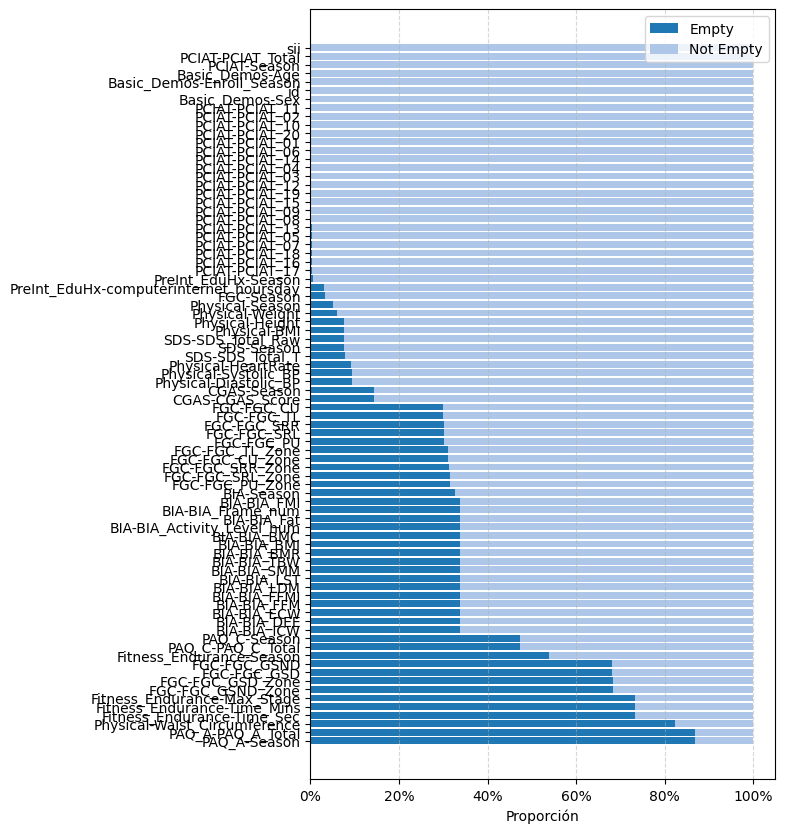

In [7]:
#6 Se revisa cantidad de nulos en cada variable con respecto de la vairable objetivo
empty = []

# A. Se calcula la proporción de valores nulos y no nulos para cada columna
for column in df_train.columns:
    empty.append((column, df_train[column].isnull().mean(), df_train[column].notnull().mean()))

# B. Se crea un DataFrame para visualizar los resultados
empty_df = pd.DataFrame(empty, columns=["Column", "Empty", "Not_Empty"])
empty_df = empty_df.sort_values(by="Empty", ascending=False)
print(empty_df.to_string())

# Se visualiza la proporción de valores nulos y no nulos para cada columna
missing_color = '#1f77b4'
available_color = '#aec7e8'

plt.figure(figsize=(6, 10))
y_pos = np.arange(len(empty_df))

plt.barh(y_pos, empty_df["Empty"], label="Empty", color=missing_color)
plt.barh(y_pos, empty_df["Not_Empty"], left=empty_df["Empty"], label="Not Empty", color=available_color)
plt.yticks(y_pos, empty_df["Column"])
plt.xlabel("Proporción")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend()


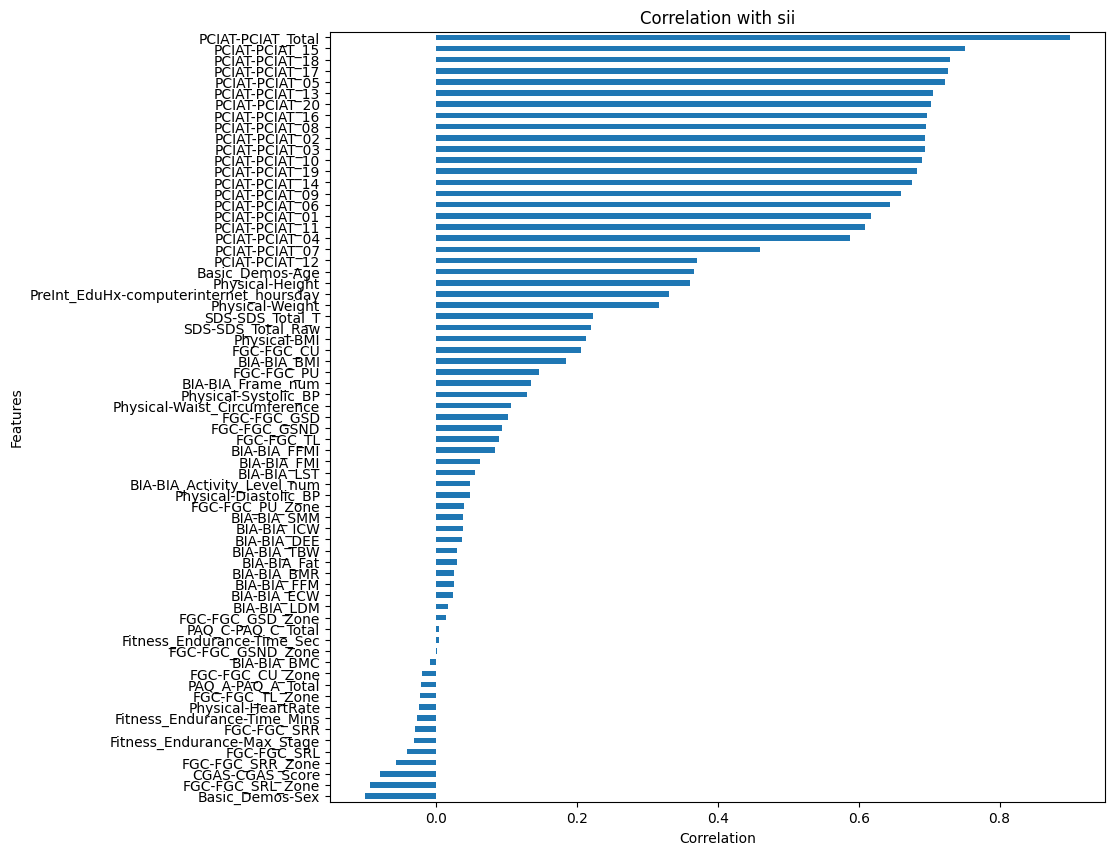

,feature,correlation,direction,strength,abs_correlation
0,PCIAT-PCIAT_Total,0.899681,positive,very strong,0.899681
1,PCIAT-PCIAT_15,0.750544,positive,very strong,0.750544
2,PCIAT-PCIAT_18,0.730237,positive,very strong,0.730237
3,PCIAT-PCIAT_17,0.726351,positive,very strong,0.726351
4,PCIAT-PCIAT_05,0.721932,positive,very strong,0.721932
5,PCIAT-PCIAT_13,0.704838,positive,very strong,0.704838
6,PCIAT-PCIAT_20,0.702466,positive,very strong,0.702466
7,PCIAT-PCIAT_16,0.697696,positive,strong,0.697696
8,PCIAT-PCIAT_08,0.695094,positive,strong,0.695094
9,PCIAT-PCIAT_02,0.694453,positive,strong,0.694453


In [8]:
df_num = df_train.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())
df_eda = df_num.loc[:, df_num.nunique() > 1]
corr = df_eda.corr()
target = "sii"
num_analysis(df_eda, target)
corr_table = num_correlation_classifier(
    df_eda,
    target,
    threshold=0.0
)
with pd.option_context(
    'display.max_rows', None,
    'display.expand_frame_repr', False
):
    display(corr_table)

In [10]:
df_num = df_train.select_dtypes(include=np.number)
df_num = df_num.fillna(df_num.mean())
df_eda = df_num.loc[:, df_num.nunique() > 1]
corr_matrix = df_eda.corr()

corr_matrix_eda = df_eda.select_dtypes(include=[np.number]).corr()
top_corrs = get_top_correlations(corr_matrix_eda)
strong_corrs = top_corrs[top_corrs['Correlation'].abs() > 0.9]
with pd.option_context('display.max_rows', None, 'display.expand_frame_repr', False):
    display(strong_corrs)

,Feature 1,Feature 2,Correlation
0,BIA-BIA_BMR,BIA-BIA_FFM,1.000000
1,BIA-BIA_BMR,BIA-BIA_TBW,0.999652
2,BIA-BIA_FFM,BIA-BIA_TBW,0.999652
3,BIA-BIA_ECW,BIA-BIA_FFM,0.999182
4,BIA-BIA_BMR,BIA-BIA_ECW,0.999182
5,BIA-BIA_ECW,BIA-BIA_TBW,0.999021
6,BIA-BIA_FFM,BIA-BIA_LDM,0.998821
7,BIA-BIA_BMR,BIA-BIA_LDM,0.998821
8,BIA-BIA_ICW,BIA-BIA_TBW,0.998337
9,BIA-BIA_ECW,BIA-BIA_LDM,0.997658


In [ ]:
base_path = "Data/series_train.parquet"
folder_paths = glob.glob(f"{base_path}/id=*")
all_ids = [path.split("id=")[-1] for path in folder_paths]

# Configuración HDCZA
WINDOW_5MIN = 60 
MIN_SLEEP_BLOCK = 360 
BATCH_SIZE = 20 # Aumentado para mayor paralelismo si tienes RAM suficiente

def process_batch(batch_ids):
    batch_files = [f"{base_path}/id={node_id}/*.parquet" for node_id in batch_ids]
    
    # 1. Usamos scan_parquet con selección de columnas para no cargar datos basura
    query = (
        pl.scan_parquet(batch_files, include_file_paths="path")
        .select([
            pl.col("path").str.extract(r"id=([^/]+)", 1).alias("id"),
            pl.col("relative_date_PCIAT"),
            pl.col("weekday"),
            pl.col("anglez"),
            pl.col("enmo"),
            ((pl.col("time_of_day") / 1e9) / 3600).alias("hour_decimal")
        ])
        # 2. Operaciones HDCZA optimizadas
        .with_columns([
            pl.col("anglez").diff().abs()
              .rolling_median(window_size=WINDOW_5MIN, center=True)
              .over(["id", "relative_date_PCIAT"])
              .alias("z_angle_var")
        ])
        .with_columns([
            (pl.col("z_angle_var").quantile(0.1).over(["id", "relative_date_PCIAT"]) * 15).alias("thr")
        ])
        .with_columns([
            (pl.col("z_angle_var") < pl.col("thr"))
              .rolling_sum(window_size=MIN_SLEEP_BLOCK, center=True)
              .over(["id", "relative_date_PCIAT"])
              .gt(MIN_SLEEP_BLOCK * 0.9)
              .alias("is_sleep")
        ])
        # 3. Agregación multinivel en una sola pasada
        .group_by(["id", "relative_date_PCIAT", "weekday"])
        .agg([
            (pl.col("is_sleep").sum() * 5 / 3600).alias("sleep_hrs"),
            pl.col("hour_decimal").filter(pl.col("is_sleep")).mean().alias("midpoint"),
            (pl.col("enmo").filter((pl.col("is_sleep") == False) & (pl.col("enmo") >= 0.1)).count() * 5 / 3600).alias("mvpa_hrs"),
            (pl.col("enmo").filter((pl.col("is_sleep") == False) & (pl.col("enmo") < 0.03)).count() * 5 / 3600).alias("sed_hrs"),
            pl.col("enmo").max().alias("peak_e")
        ])
        .group_by("id")
        .agg([
            pl.col("mvpa_hrs").mean().alias("avg_mvpa_hours"),
            pl.col("sed_hrs").mean().alias("avg_sedentary_hours"),
            pl.col("peak_e").max().alias("max_intensity_recorded"),
            pl.col("sleep_hrs").filter(pl.col("weekday") <= 5).mean().alias("avg_sleep_weekday"),
            pl.col("sleep_hrs").filter(pl.col("weekday") > 5).mean().alias("avg_sleep_weekend"),
            pl.col("midpoint").filter(pl.col("weekday") <= 5).mean().alias("mid_wd"),
            pl.col("midpoint").filter(pl.col("weekday") > 5).mean().alias("mid_we"),
            pl.col("sleep_hrs").mean().alias("g_sleep"),
            pl.col("sleep_hrs").std().alias("std_sleep")
        ])
        .with_columns([
            (pl.col("mid_wd") - pl.col("mid_we")).abs().alias("social_jetlag"),
            (pl.col("avg_sedentary_hours") / (pl.col("avg_mvpa_hours") + pl.col("avg_sedentary_hours") + 1e-6)).alias("sedentary_ratio"),
            (pl.col("std_sleep") / (pl.col("g_sleep") + 1e-6)).alias("sleep_instability_index")
        ])
    )
    return query

# Ejecución por lotes con LazyFrames
all_dfs = []
for i in range(0, len(all_ids), BATCH_SIZE):
    batch = all_ids[i : i + BATCH_SIZE]
    # .collect(streaming=True) es vital para archivos que no caben en RAM
    df_result = process_batch(batch).collect(streaming=True)
    all_dfs.append(df_result.to_pandas())
    print(f"Progreso: {i + len(batch)} / {len(all_ids)} IDs")
    gc.collect()


C:\Users\PAPELERIA GENESIS\AppData\Local\Temp\ipykernel_17556\3773554762.py:75: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  df_result = process_batch(batch).collect(streaming=True)


Progreso: 20 / 996 IDs
Progreso: 40 / 996 IDs
Progreso: 60 / 996 IDs
Progreso: 80 / 996 IDs
Progreso: 100 / 996 IDs
Progreso: 120 / 996 IDs
Progreso: 140 / 996 IDs
Progreso: 160 / 996 IDs
Progreso: 180 / 996 IDs
Progreso: 200 / 996 IDs
Progreso: 220 / 996 IDs
Progreso: 240 / 996 IDs
Progreso: 260 / 996 IDs
Progreso: 280 / 996 IDs
Progreso: 300 / 996 IDs
Progreso: 320 / 996 IDs
Progreso: 340 / 996 IDs
Progreso: 360 / 996 IDs
Progreso: 380 / 996 IDs
Progreso: 400 / 996 IDs
Progreso: 420 / 996 IDs
Progreso: 440 / 996 IDs
Progreso: 460 / 996 IDs
Progreso: 480 / 996 IDs
Progreso: 500 / 996 IDs
Progreso: 520 / 996 IDs
Progreso: 540 / 996 IDs
Progreso: 560 / 996 IDs
Progreso: 580 / 996 IDs
Progreso: 600 / 996 IDs
Progreso: 620 / 996 IDs
Progreso: 640 / 996 IDs
Progreso: 660 / 996 IDs
Progreso: 680 / 996 IDs
Progreso: 700 / 996 IDs
Progreso: 720 / 996 IDs
Progreso: 740 / 996 IDs
Progreso: 760 / 996 IDs
Progreso: 780 / 996 IDs
Progreso: 800 / 996 IDs
Progreso: 820 / 996 IDs
Progreso: 840 / 996 

In [207]:
df_final_features = pd.concat(all_dfs, ignore_index=True)
df_final_features[["avg_sleep_weekday", "avg_sleep_weekend"]] = df_final_features[["avg_sleep_weekday", "avg_sleep_weekend"]].clip(lower=2, upper=16)
df_final_features.head()

,id,avg_mvpa_hours,avg_sedentary_hours,max_intensity_recorded,avg_sleep_weekday,avg_sleep_weekend,mid_wd,mid_we,g_sleep,std_sleep,social_jetlag,sedentary_ratio,sleep_instability_index
0,02cf7384,1.435532,10.473032,2.434495,6.974479,11.992188,10.473478,8.904468,8.647049,4.325548,1.569010,0.879454,0.500234
1,04afb6f9,1.971667,7.989556,2.592310,7.551235,7.404762,7.212919,4.826351,7.510222,3.535406,2.386568,0.802066,0.470746
2,04cb2c30,1.749306,8.173032,3.364508,9.197970,9.047083,6.312367,5.834917,9.156057,3.823826,0.477450,0.823700,0.417628
3,01085eb3,1.904589,9.648309,4.097965,6.902859,7.956250,8.212380,8.206558,7.177657,2.115870,0.005822,0.835142,0.294786
4,03a9019b,2.385417,8.792130,4.409585,7.731699,7.461508,5.643712,5.163801,7.652894,1.186683,0.479912,0.786588,0.155063


In [209]:
df_final_features.describe()

,avg_mvpa_hours,avg_sedentary_hours,max_intensity_recorded,avg_sleep_weekday,avg_sleep_weekend,mid_wd,mid_we,g_sleep,std_sleep,social_jetlag,sedentary_ratio,sleep_instability_index
count,996.000000,996.000000,996.000000,996.000000,979.000000,995.000000,965.000000,996.000000,994.000000,964.000000,996.000000,994.000000
mean,0.900262,5.652530,3.674156,8.899410,9.391676,11.178035,10.868324,9.010339,4.795408,1.360546,0.773359,0.716876
std,0.965469,4.188674,1.459785,3.531270,3.874083,2.633123,3.141107,3.858975,2.384171,1.377760,0.242949,0.716424
min,0.000000,0.000000,0.140138,2.000000,2.000000,4.313528,2.393056,0.005978,0.028671,0.000587,0.000000,0.116191
25%,0.024504,0.088162,2.790156,7.180599,7.366944,9.187932,8.319259,7.463856,2.762561,0.460425,0.729343,0.352686
50%,0.543403,7.189497,3.806256,8.740617,9.150000,11.396954,10.873367,8.827836,4.659208,1.040644,0.838271,0.531968
75%,1.635199,8.963067,4.593709,11.203972,12.247604,13.276356,13.367393,11.394444,6.633775,1.796088,0.923198,0.723811
max,4.184300,14.351444,11.326200,16.000000,16.000000,20.087062,20.804521,21.392535,11.566541,15.955185,0.999947,7.549768


In [211]:
df_train = df_train.merge(df_final_features, on="id", how="left")

In [212]:

#Feature Engenering

df_train['Basic_Demos-Age_Physical-BMI_mul']= df_train['Basic_Demos-Age']*df_train['Physical-BMI']
df_train['Physical-Weight_avg_sleep_weekend_mul']= df_train['Physical-Weight']*df_train['avg_sleep_weekend']
df_train['avg_sleep_weekend_Basic_Demos-Age_mul']= df_train['avg_sleep_weekend']*df_train['Basic_Demos-Age']
df_train['SDS-SDS_Total_T_Basic_Demos-Age_mul']= df_train['SDS-SDS_Total_T']*df_train['Basic_Demos-Age']
df_train['Physical-Weight_Physical-HeartRate_div']= df_train['Physical-Weight']/(df_train['Physical-HeartRate']+ 1e-6)
df_train['avg_sleep_weekend_FGC-FGC_SRR_div']= df_train['avg_sleep_weekend']/(df_train['FGC-FGC_SRR']+ 1e-6)
df_train['jet_lag_diff']= df_train['avg_sleep_weekend']-df_train['avg_sleep_weekday']


In [213]:
# 5. Clasificación de features (SII).
unused_features = [
    # indicadores derivados
    'PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 
    'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 
    'PCIAT-PCIAT_06', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 
    'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_11', 
    'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14', 
    'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 
    'PCIAT-PCIAT_18', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 
    'PCIAT-PCIAT_Total',


    # Variables con demasiados nulos
    'PAQ_A-Season',
    'PAQ_A-PAQ_A_Total',
    'Physical-Waist_Circumference',
    'Fitness_Endurance-Time_Sec',
    'Fitness_Endurance-Time_Mins',
    'Fitness_Endurance-Max_Stage',

    # identificadores
    'id',

    #Correlación muy elevada entre variables (Infomación redundante)
    'SDS-SDS_Total_Raw', 'BIA-BIA_DEE','BIA-BIA_ECW',
    'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM'
]

#---------------------------------------------------------------------------------------------------------

numeric_features = [
 'Basic_Demos-Age', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 
 'Physical-Weight', 'Physical-HeartRate', 'Physical-Diastolic_BP', 
 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 
 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_BMC', 
 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_FFM', 
 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
 'BIA-BIA_TBW', 'PAQ_C-PAQ_C_Total', 
 'SDS-SDS_Total_T',  'avg_mvpa_hours', 'avg_sedentary_hours', 'max_intensity_recorded',
       'avg_sleep_weekday', 'avg_sleep_weekend', 'mid_wd', 'mid_we', 'g_sleep',
       'std_sleep', 'social_jetlag', 'sedentary_ratio',
       'sleep_instability_index',

'SDS-SDS_Total_T_Basic_Demos-Age_mul','avg_sleep_weekend_Basic_Demos-Age_mul','Physical-Weight_Physical-HeartRate_div',
'avg_sleep_weekend_FGC-FGC_SRR_div','Basic_Demos-Age_Physical-BMI_mul','Physical-Weight_avg_sleep_weekend_mul','jet_lag_diff'

]

#---------------------------------------------------------------------------------------------------------

categorical_features = [
 'Basic_Demos-Enroll_Season', 'Basic_Demos-Sex', 'CGAS-Season', 
 'Physical-Season', 'FGC-Season', 'Fitness_Endurance-Season', 'BIA-Season', 
 'PAQ_C-Season', 'PreInt_EduHx-Season', 'SDS-Season',

]

#---------------------------------------------------------------------------------------------------------

ordinal_features = [
 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone', 
'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 
'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
 'PreInt_EduHx-computerinternet_hoursday'
]


In [214]:
X = df_train.drop(columns=["sii"])
y = df_train["sii"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [215]:
# 6. Definición de Pipelines de Imputación, Escalado y Encoding.
# a. Pipeline de limpieza.
dataset_cleaning_pipeline = Pipeline(steps=[
    ("drop_unused", drop_features_transformer)
])
# numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categóricas nominales
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ordinales (sin one hot)
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
    ('ord', ord_pipeline, ordinal_features)
])
# e. Process PipeLine: une el pipeline de limpieza inicial con preprocessor.
process_pipeline = Pipeline(steps=[
    ("clean", dataset_cleaning_pipeline),
    ("preprocessor", preprocessor)
])
# f. Implementación del Pipeline.
X_train = process_pipeline.fit_transform(X_train_raw)
X_train = pd.DataFrame(
    X_train,
    columns=preprocessor.get_feature_names_out()
    )

X_test = process_pipeline.transform(X_test_raw)
X_test = pd.DataFrame(
    X_test,
    columns=preprocessor.get_feature_names_out()
    )

process_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_unused', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...001204BEE6AC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This

         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD - CROSS VALIDATION (K=5)]
  > Accuracy: 0.5283 ± 0.0380
  > QWK: 0.3806 ± 0.0781

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       336
           1       0.29      0.30      0.29       131
           2       0.27      0.40      0.32        72
           3       0.10      0.33      0.15         9

    accuracy                           0.52       548
   macro avg       0.36      0.42      0.37       548
weighted avg       0.59      0.52      0.55       548



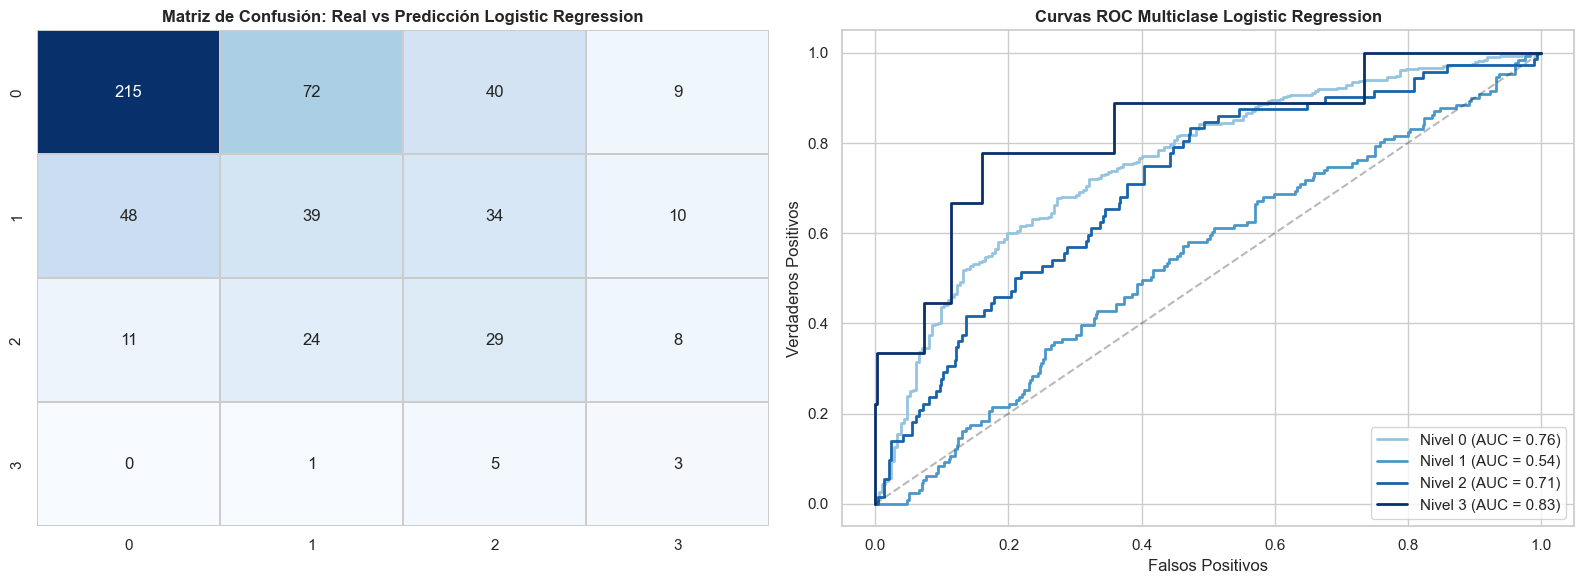

In [216]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

qwk_scorer = make_scorer(quadratic_weighted_kappa)

scoring_metrics = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'quadratic_kappa': qwk_scorer
}



logistic_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logistic_model.fit(X_train, y_train)
y_pres_lg = logistic_model.predict(X_test)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(logistic_model, X_train, y_train, cv=skf, scoring=scoring_metrics)

display_professional_eval(logistic_model, "Logistic Regression", X_test, y_test, y_pres_lg, cv_results, X_train.columns)

In [72]:
param_grid = {
    'n_estimators': [300, 200],
    'max_depth': [15, 10, 5], # Controlado pero suficiente para aprender
    'min_samples_split': [5,4], # Valores más bajos para permitir nodos pequeños
    'min_samples_leaf': [1, 4,3],  # Permitir que hojas de 1 o 2 ejemplos existan
    'class_weight': ['balanced_subsample'] # CLAVE para multiclase
}

rf_model = RandomForestClassifier(random_state=42)

grid = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring=qwk_scorer, n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Quadratic Weighted Kappa CV:", grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 300}
Quadratic Weighted Kappa CV: 0.4145168086792209


         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD - CROSS VALIDATION (K=5)]
  > Accuracy: 0.5731 ± 0.0465
  > QWK: 0.4000 ± 0.0978

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       336
           1       0.30      0.36      0.33       131
           2       0.29      0.29      0.29        72
           3       0.50      0.22      0.31         9

    accuracy                           0.57       548
   macro avg       0.46      0.40      0.42       548
weighted avg       0.59      0.57      0.57       548



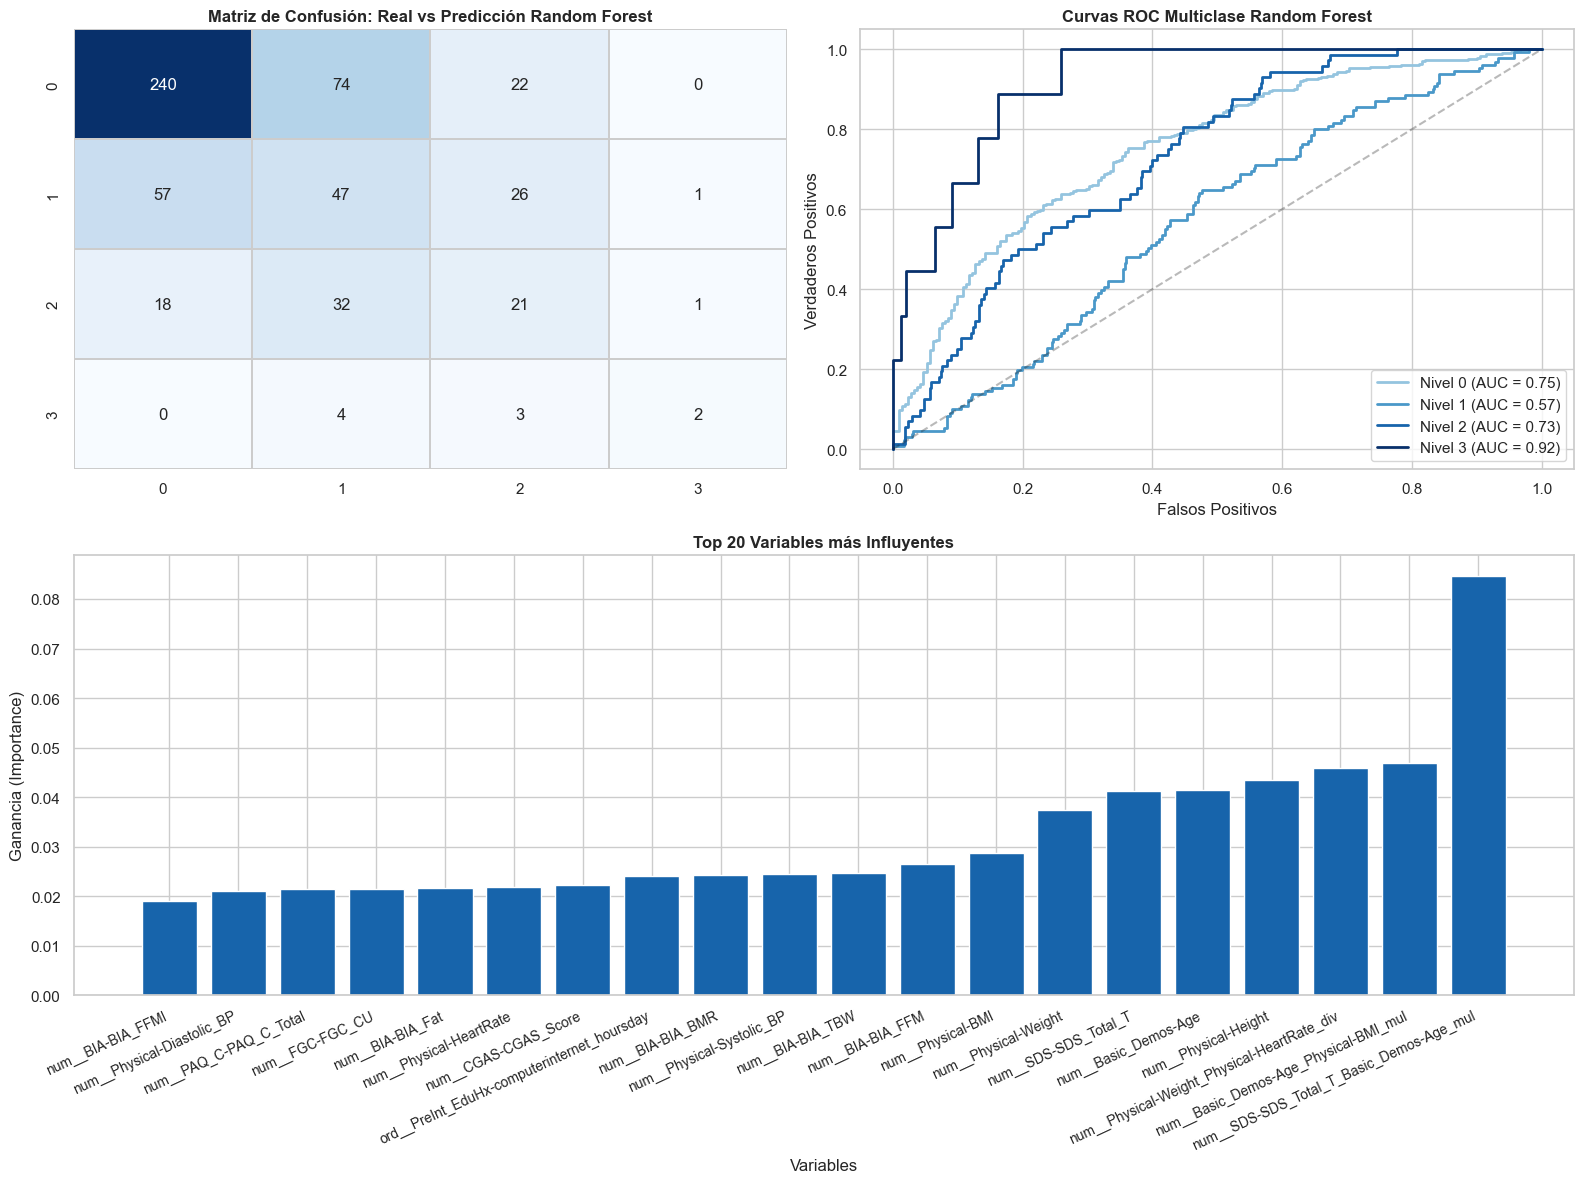

,Feature,Importance
37,num__SDS-SDS_Total_T_Basic_Demos-Age_mul,0.084592
41,num__Basic_Demos-Age_Physical-BMI_mul,0.046930
39,num__Physical-Weight_Physical-HeartRate_div,0.045910
3,num__Physical-Height,0.043439
0,num__Basic_Demos-Age,0.041407
24,num__SDS-SDS_Total_T,0.041285
4,num__Physical-Weight,0.037300
2,num__Physical-BMI,0.028764
18,num__BIA-BIA_FFM,0.026513
22,num__BIA-BIA_TBW,0.024715


In [217]:
model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

cv_results_rf = cross_validate(
    model_rf,
    X_train, y_train,
    cv=skf,
    scoring=scoring_metrics
)

display_professional_eval(
    model_rf,
    "Random Forest",
    X_test,
    y_test,
    y_pred_rf,
    cv_results_rf,
    X_train.columns
)


In [96]:
param_distr = {
    'n_estimators': [700, 600],
    'learning_rate': [0.01, 0.015],
    'max_depth': [4, 5, 9],
    'min_child_weight': [ 2, 5],
    'subsample': [0.8, 0.7],
    'colsample_bytree': [0.7, 0.8],
    'objective': ['multi:softprob']
}

XB_model = XGBClassifier(
    random_state=42
)

grid = RandomizedSearchCV(estimator=XB_model, param_distributions=param_distr,n_iter=30,cv=3, scoring=qwk_scorer,random_state=42, n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)
print("Mejores parámetros:", grid.best_params_)
print("Quadratic Weighted Kappa CV:", grid.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros: {'subsample': 0.7, 'objective': 'multi:softprob', 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.015, 'colsample_bytree': 0.8}
Quadratic Weighted Kappa CV: 0.3532292177631174


         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD - CROSS VALIDATION (K=5)]
  > Accuracy: 0.6033 ± 0.0377
  > QWK: 0.3415 ± 0.1246

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       336
           1       0.30      0.34      0.32       131
           2       0.29      0.38      0.33        72
           3       0.25      0.44      0.32         9

    accuracy                           0.56       548
   macro avg       0.41      0.46      0.43       548
weighted avg       0.61      0.56      0.58       548



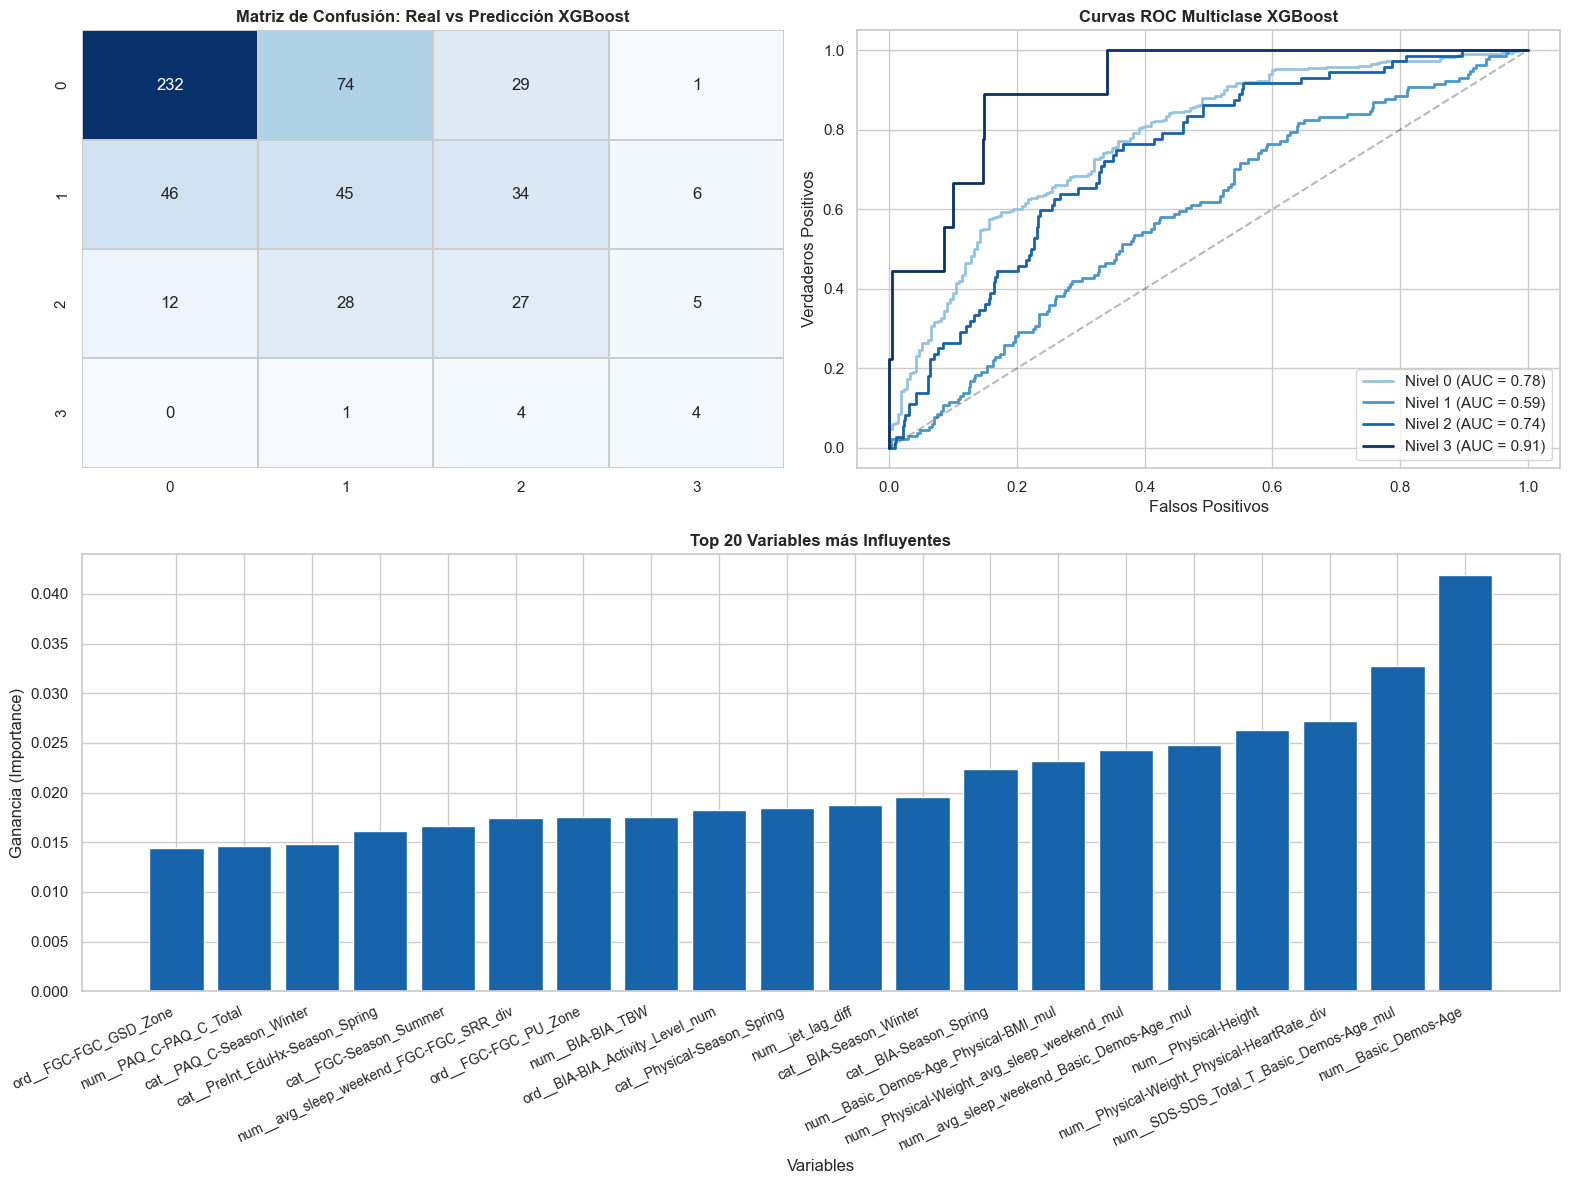

,Feature,Importance
0,num__Basic_Demos-Age,0.041939
37,num__SDS-SDS_Total_T_Basic_Demos-Age_mul,0.032744
39,num__Physical-Weight_Physical-HeartRate_div,0.027190
3,num__Physical-Height,0.026317
38,num__avg_sleep_weekend_Basic_Demos-Age_mul,0.024778
42,num__Physical-Weight_avg_sleep_weekend_mul,0.024327
41,num__Basic_Demos-Age_Physical-BMI_mul,0.023177
60,cat__BIA-Season_Spring,0.022384
62,cat__BIA-Season_Winter,0.019513
43,num__jet_lag_diff,0.018726


In [218]:
# 1. Calculamos pesos para cada clase basándonos en tu 'support'
# Esto compensa que tengas 336 de una y solo 9 de otra
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), weights))

# 2. XGBoost Optimizado
# Bajamos Max Depth para que no se sobreajuste a los pocos casos de la clase 3
# Subimos n_estimators con un learning_rate pequeño
model_XG = xgb.XGBClassifier(
    n_estimators=700,
    learning_rate=0.015,
    max_depth=3, 
    min_child_weight=6, 
    subsample=0.7,
    colsample_bytree=0.8,
    objective='multi:softprob',
    random_state=42,
    reg_alpha=0.2,
    reg_lambda=1
)

# 3. Entrenamiento con pesos de muestra
sample_weights = np.array([class_weights[y] for y in y_train])

model_XG.fit(
    X_train, y_train, 
    sample_weight=sample_weights
)

y_pred_XG = model_XG.predict(X_test)


cv_results_XG = cross_validate(
    model_XG,
    X_train, y_train,
    cv=skf,
    scoring=scoring_metrics,
)

display_professional_eval(
    model_XG,
    "XGBoost",
    X_test,
    y_test,
    y_pred_XG,
    cv_results_XG,
    X_train.columns
)

In [114]:
param_grid = {
        'C': [0.1, 1, 10, 50],
        'gamma': ['scale', 0.01, 0.1, 1],
}

svm_model = svm.SVC(kernel='rbf', random_state=42)

grid = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, scoring=qwk_scorer, n_jobs=-1, verbose=2)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Quadratic Weighted Kappa CV:", grid.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros: {'C': 10, 'gamma': 0.01}
Quadratic Weighted Kappa CV: 0.30532078184977063


         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD - CROSS VALIDATION (K=5)]
  > Accuracy: 0.5421 ± 0.0322
  > QWK: 0.3334 ± 0.0573

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       336
           1       0.31      0.36      0.33       131
           2       0.26      0.29      0.28        72
           3       0.20      0.11      0.14         9

    accuracy                           0.55       548
   macro avg       0.38      0.36      0.37       548
weighted avg       0.57      0.55      0.56       548



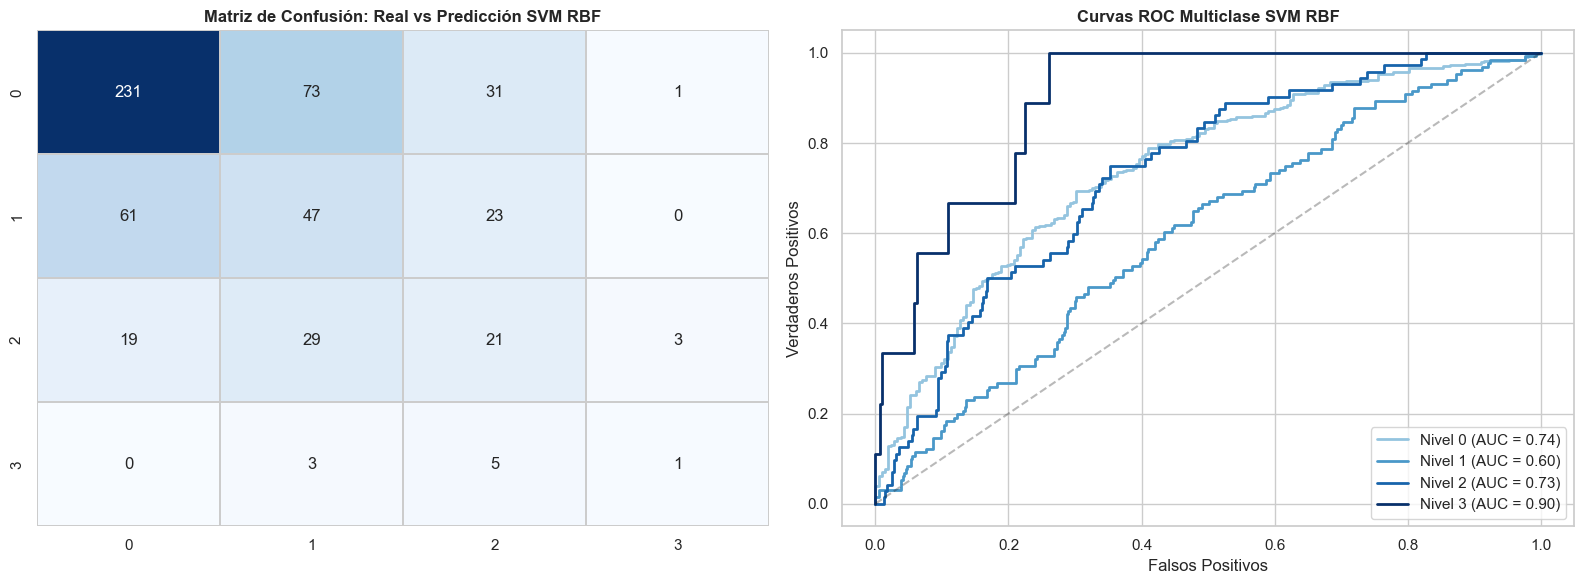

In [219]:
svc_linear = svm.SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=42, probability=True)
svc_linear.fit(X_train, y_train)
y_pred_svc = svc_linear.predict(X_test)

cv_results_SVC = cross_validate(
    svc_linear,
    X_train, y_train,
    cv=skf,
    scoring=scoring_metrics,
)

display_professional_eval(
    svc_linear,
    "SVM RBF",
    X_test, 
    y_test,
    y_pred_svc,
    cv_results_SVC,
    X_train.columns
)

         REPORTE DE CLASIFICACIÓN DE DESEMPEÑO SII          

[ESTABILIDAD - CROSS VALIDATION (K=5)]
  > Accuracy: 0.8643 ± 0.0442
  > QWK: 0.7785 ± 0.0917

[DESEMPEÑO EN SET DE PRUEBA]
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       336
           1       0.30      0.36      0.33       131
           2       0.29      0.29      0.29        72
           3       0.50      0.22      0.31         9

    accuracy                           0.57       548
   macro avg       0.46      0.40      0.42       548
weighted avg       0.59      0.57      0.57       548



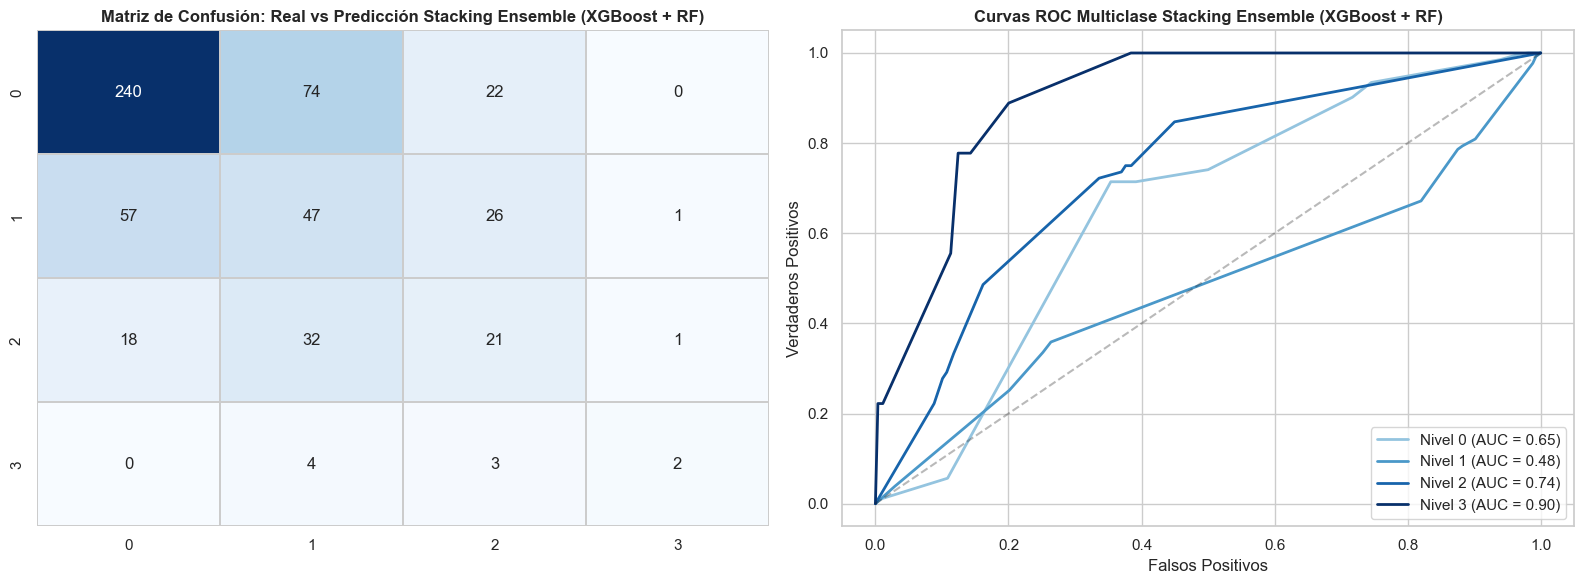

In [220]:
# Crea el meta-dataset con tus modelos entrenados con el nuevo calendario
meta_X_train = np.column_stack([
    model_XG.predict(X_train),
    model_rf.predict(X_train),
])

meta_X_test = np.column_stack([
    model_XG.predict(X_test),
    model_rf.predict(X_test),
])
    

# Meta-modelo (Regresión Logística para decidir)
meta_model = LogisticRegression(class_weight='balanced')
meta_model.fit(meta_X_train, y_train)

y_pred_stack = meta_model.predict(meta_X_test)

cv_results_STACK = cross_validate(
    meta_model,
    meta_X_train, y_train,
    cv=skf,
    scoring=scoring_metrics,
)

display_professional_eval(
    meta_model,
    "Stacking Ensemble (XGBoost + RF)",
    meta_X_test,
    y_test,
    y_pred_stack,
    cv_results_STACK,
    X_train.columns
)

In [221]:
y_pred = [y_pres_lg, y_pred_rf, y_pred_XG, y_pred_svc, y_pred_stack]
models = ["Logistic Regression", "Random Forest", "XGBoost", "SVM", "Stacking"]

comparison = compare_models(y_test, y_pred, models)
display(comparison)

,Model,Accuracy,QWK,f1_Score
0,Logistic Regression,0.521898,0.388834,0.546910
1,Random Forest,0.565693,0.413535,0.573482
2,XGBoost,0.562044,0.473655,0.579576
3,SVM,0.547445,0.367941,0.555873
4,Stacking,0.565693,0.413535,0.573482
